# USGS Data Analysis and Comparison

This notebook analyzes new USGS stream and groundwater data and compares it with existing Santa Barbara County sites.
It processes two text files: stream sites and groundwater sites.


## Imports and setup

In [1]:
# Standard imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import re

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries loaded successfully")

Libraries loaded successfully


## Load USGS data files

In [2]:
# ==== Load USGS Stream and Groundwater Data ====
print("=== LOADING USGS DATA FILES ===")
from pathlib import Path

stream_file = Path(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_usgs\sb_streams.txt")
groundwater_file = Path(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_usgs\entire_usa_2022.txt")  

# Function to safely load text files with multiple encoding attempts
def load_text_file(filepath, delimiter='\t'):
    """Load text file with fallback encoding options"""
    encodings = ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']
    
    for encoding in encodings:
        try:
            df = pd.read_csv(filepath, delimiter=delimiter, encoding=encoding, low_memory=False)
            print(f"Successfully loaded {filepath} with {encoding} encoding")
            return df
        except UnicodeDecodeError:
            continue
        except Exception as e:
            print(f"Error loading {filepath} with {encoding}: {e}")
            continue
    
    raise ValueError(f"Could not load {filepath} with any encoding")

# Load the files (uncomment when you have the actual file paths)
stream_data = load_text_file(stream_file)
groundwater_data = load_text_file(groundwater_file)

# Once loaded, display basic info
if stream_data is not None:
    print(f"\nStream data shape: {stream_data.shape}")
    print("Stream data columns:")
    print(stream_data.columns.tolist())
    display(stream_data.head(3))

if groundwater_data is not None:
    print(f"\nGroundwater data shape: {groundwater_data.shape}")
    print("Groundwater data columns:")
    print(groundwater_data.columns.tolist())
    display(groundwater_data.head(3))

=== LOADING USGS DATA FILES ===
Successfully loaded C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_usgs\sb_streams.txt with utf-8 encoding
Successfully loaded C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_usgs\entire_usa_2022.txt with utf-8 encoding

Stream data shape: (570, 15)
Stream data columns:
['agency_cd', 'site_no', 'station_nm', 'site_tp_cd', 'dec_lat_va', 'dec_long_va', 'coord_acy_cd', 'dec_coord_datum_cd', 'county_cd', 'peak_begin_date', 'peak_end_date', 'peak_count_nu', 'gw_begin_date', 'gw_end_date', 'gw_count_nu']


,agency_cd,site_no,station_nm,site_tp_cd,dec_lat_va,dec_long_va,coord_acy_cd,dec_coord_datum_cd,county_cd,peak_begin_date,peak_end_date,peak_count_nu,gw_begin_date,gw_end_date,gw_count_nu
0,USGS,9423350,CARUTHERS C NR IVANPAH CA,ST,35.245006,-115.298989,5,NAD83,71,1963-10-18,2024-02-20,61,--,--,0
1,USGS,10253000,GOURD C NR LUDLOW CA,ST,34.676379,-116.023062,F,NAD83,71,1959,2024,62,--,--,0
2,USGS,10254050,SALT C NR MECCA,ST,33.446984,-115.843323,F,NAD83,65,1962-09-27,1990-06-09,29,--,--,0



Groundwater data shape: (10508313, 34)
Groundwater data columns:
['agency_cd.x', 'site_no', 'station_nm', 'dec_lat_va', 'dec_long_va', 'coord_acy_cd', 'dec_coord_datum_cd', 'state_cd', 'alt_va', 'alt_acy_va', 'alt_datum_cd', 'well_depth_va', 'hole_depth_va', 'id.x', 'agency_cd.y', 'site_tp_cd', 'lev_dt', 'lev_tm', 'lev_tz_cd', 'lev_va', 'sl_lev_va', 'sl_datum_cd', 'lev_status_cd', 'lev_agency_cd', 'lev_dt_acy_cd', 'lev_acy_cd', 'lev_src_cd', 'lev_meth_cd', 'lev_age_cd', 'id.y', 'level_date', 'level_decimal_date', 'level_month', 'level_year']


,agency_cd.x,site_no,station_nm,dec_lat_va,dec_long_va,coord_acy_cd,dec_coord_datum_cd,state_cd,alt_va,alt_acy_va,alt_datum_cd,well_depth_va,hole_depth_va,id.x,agency_cd.y,site_tp_cd,lev_dt,lev_tm,lev_tz_cd,lev_va,sl_lev_va,sl_datum_cd,lev_status_cd,lev_agency_cd,lev_dt_acy_cd,lev_acy_cd,lev_src_cd,lev_meth_cd,lev_age_cd,id.y,level_date,level_decimal_date,level_month,level_year
0,USGS,515150176385301,MRP-MW14 ADAK AK SC09619514B,51.862510,-176.650529,M,NAD83,2.0,5.0,30.0,NGVD29,NaN,NaN,ak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USGS,515155176383401,ADAK ISLAND TEST HOLE FPP12,51.863899,-176.645251,5,NAD83,2.0,30.0,5.0,NGVD29,25,25,ak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USGS,515155176383901,ADAK ISLAND WELL 01-118,51.863899,-176.646640,5,NAD83,2.0,30.0,5.0,NGVD29,25,25,ak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data exploration and coordinate identification

In [3]:
# ==== Explore USGS Data Structure ====
print("=== USGS DATA EXPLORATION ===")

def explore_dataframe(df, name):
    """Explore dataframe structure and identify potential coordinate columns"""
    if df is None:
        print(f"{name}: No data loaded yet")
        return
    
    print(f"\n{name.upper()} DATA:")
    print(f"Shape: {df.shape}")
    print(f"Columns ({len(df.columns)}): {df.columns.tolist()}")
    
    # Look for coordinate columns
    coord_patterns = {
        'latitude': r'(?i)lat|latitude|y_coord|northing|lat_dd',
        'longitude': r'(?i)lon|lng|longitude|x_coord|easting|long_dd|lon_dd'
    }
    
    potential_coords = {}
    for coord_type, pattern in coord_patterns.items():
        matches = [col for col in df.columns if re.search(pattern, str(col))]
        if matches:
            potential_coords[coord_type] = matches
    
    if potential_coords:
        print(f"Potential coordinate columns:")
        for coord_type, cols in potential_coords.items():
            print(f"  {coord_type}: {cols}")
    else:
        print("No obvious coordinate columns found - manual inspection needed")
    
    # Show data types
    print(f"\nData types:")
    for col in df.columns[:10]:  # First 10 columns
        dtype = df[col].dtype
        non_null = df[col].notna().sum()
        print(f"  {col}: {dtype} ({non_null:,}/{len(df):,} non-null)")
    
    if len(df.columns) > 10:
        print(f"  ... and {len(df.columns) - 10} more columns")
    
    # Show sample data
    print(f"\nFirst few rows:")
    return df.head()

# Explore both datasets
if stream_data is not None or groundwater_data is not None:
    stream_sample = explore_dataframe(stream_data, "stream")
    if stream_sample is not None:
        display(stream_sample)
    
    groundwater_sample = explore_dataframe(groundwater_data, "groundwater")
    if groundwater_sample is not None:
        display(groundwater_sample)
else:
    print("Load the data files first by updating the file paths in the previous cell")

=== USGS DATA EXPLORATION ===

STREAM DATA:
Shape: (570, 15)
Columns (15): ['agency_cd', 'site_no', 'station_nm', 'site_tp_cd', 'dec_lat_va', 'dec_long_va', 'coord_acy_cd', 'dec_coord_datum_cd', 'county_cd', 'peak_begin_date', 'peak_end_date', 'peak_count_nu', 'gw_begin_date', 'gw_end_date', 'gw_count_nu']
Potential coordinate columns:
  latitude: ['dec_lat_va']
  longitude: ['dec_long_va']

Data types:
  agency_cd: object (570/570 non-null)
  site_no: int64 (570/570 non-null)
  station_nm: object (570/570 non-null)
  site_tp_cd: object (570/570 non-null)
  dec_lat_va: float64 (570/570 non-null)
  dec_long_va: float64 (570/570 non-null)
  coord_acy_cd: object (570/570 non-null)
  dec_coord_datum_cd: object (570/570 non-null)
  county_cd: int64 (570/570 non-null)
  peak_begin_date: object (570/570 non-null)
  ... and 5 more columns

First few rows:


,agency_cd,site_no,station_nm,site_tp_cd,dec_lat_va,dec_long_va,coord_acy_cd,dec_coord_datum_cd,county_cd,peak_begin_date,peak_end_date,peak_count_nu,gw_begin_date,gw_end_date,gw_count_nu
0,USGS,9423350,CARUTHERS C NR IVANPAH CA,ST,35.245006,-115.298989,5,NAD83,71,1963-10-18,2024-02-20,61,--,--,0
1,USGS,10253000,GOURD C NR LUDLOW CA,ST,34.676379,-116.023062,F,NAD83,71,1959,2024,62,--,--,0
2,USGS,10254050,SALT C NR MECCA,ST,33.446984,-115.843323,F,NAD83,65,1962-09-27,1990-06-09,29,--,--,0
3,USGS,10255550,NEW R NR WESTMORLAND CA,ST,33.104772,-115.664426,F,NAD83,25,1962-01-25,2024-01-24,63,--,--,0
4,USGS,10256500,SNOW C NR WHITE WATER CA,ST,33.870579,-116.681127,F,NAD83,65,1922-12-14,2024-02-05,73,--,--,0



GROUNDWATER DATA:
Shape: (10508313, 34)
Columns (34): ['agency_cd.x', 'site_no', 'station_nm', 'dec_lat_va', 'dec_long_va', 'coord_acy_cd', 'dec_coord_datum_cd', 'state_cd', 'alt_va', 'alt_acy_va', 'alt_datum_cd', 'well_depth_va', 'hole_depth_va', 'id.x', 'agency_cd.y', 'site_tp_cd', 'lev_dt', 'lev_tm', 'lev_tz_cd', 'lev_va', 'sl_lev_va', 'sl_datum_cd', 'lev_status_cd', 'lev_agency_cd', 'lev_dt_acy_cd', 'lev_acy_cd', 'lev_src_cd', 'lev_meth_cd', 'lev_age_cd', 'id.y', 'level_date', 'level_decimal_date', 'level_month', 'level_year']
Potential coordinate columns:
  latitude: ['dec_lat_va']
  longitude: ['dec_long_va']

Data types:
  agency_cd.x: object (10,288,525/10,508,313 non-null)
  site_no: int64 (10,508,313/10,508,313 non-null)
  station_nm: object (10,288,521/10,508,313 non-null)
  dec_lat_va: float64 (10,283,740/10,508,313 non-null)
  dec_long_va: float64 (10,283,740/10,508,313 non-null)
  coord_acy_cd: object (10,284,022/10,508,313 non-null)
  dec_coord_datum_cd: object (10,283,

,agency_cd.x,site_no,station_nm,dec_lat_va,dec_long_va,coord_acy_cd,dec_coord_datum_cd,state_cd,alt_va,alt_acy_va,alt_datum_cd,well_depth_va,hole_depth_va,id.x,agency_cd.y,site_tp_cd,lev_dt,lev_tm,lev_tz_cd,lev_va,sl_lev_va,sl_datum_cd,lev_status_cd,lev_agency_cd,lev_dt_acy_cd,lev_acy_cd,lev_src_cd,lev_meth_cd,lev_age_cd,id.y,level_date,level_decimal_date,level_month,level_year
0,USGS,515150176385301,MRP-MW14 ADAK AK SC09619514B,51.862510,-176.650529,M,NAD83,2.0,5.0,30.0,NGVD29,NaN,NaN,ak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USGS,515155176383401,ADAK ISLAND TEST HOLE FPP12,51.863899,-176.645251,5,NAD83,2.0,30.0,5.0,NGVD29,25,25,ak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USGS,515155176383901,ADAK ISLAND WELL 01-118,51.863899,-176.646640,5,NAD83,2.0,30.0,5.0,NGVD29,25,25,ak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USGS,515155176384001,ADAK ISLAND TEST HOLE FPP11,51.863899,-176.646918,5,NAD83,2.0,30.0,5.0,NGVD29,25,25,ak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USGS,515155176384101,ADAK ISLAND TEST HOLE FPP10,51.863899,-176.647196,5,NAD83,2.0,30.0,5.0,NGVD29,25,25,ak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Count dates for GW 

In [13]:
# ==== Decadal Breakdown of Unique Sites (California Only) ====
def analyze_groundwater_decades(df, name="groundwater"):
    """Analyze unique sites by decade using level_date - California only"""
    if df is None:
        print(f"{name}: No data loaded yet")
        return None, None
    
    print(f"\n=== DECADAL BREAKDOWN OF UNIQUE {name.upper()} SITES (CALIFORNIA ONLY) ===")
    
    # Check if required columns exist
    required_columns = ['site_no', 'level_date', 'state_cd']
    missing_columns = [col for col in required_columns if col not in df.columns]
    
    if missing_columns:
        print(f"Error: Missing required columns: {missing_columns}")
        print(f"Available columns: {df.columns.tolist()}")
        return None, None
    
    # Filter for California only
    try:
        print(f"Original dataset: {len(df):,} records")
        print(f"Unique states in dataset: {sorted(df['state_cd'].unique())}")
        
        # Filter for California (state code 06 - can be string '06' or numeric 6)
        df_ca = df[(df['state_cd'] == '06') | (df['state_cd'] == 6)].copy()
        
        if len(df_ca) == 0:
            print("No California records found in dataset")
            print("Note: California state code should be '06' or 6")
            return None, None
        
        print(f"California records: {len(df_ca):,} records ({len(df_ca)/len(df)*100:.1f}% of total)")
        print(f"California unique sites: {df_ca['site_no'].nunique():,}")
        
        # Convert level_date to datetime
        df_ca['level_date'] = pd.to_datetime(df_ca['level_date'], errors='coerce')
        
        # Filter out records with invalid dates
        df_work = df_ca.dropna(subset=['level_date'])
        
        if len(df_work) == 0:
            print("No valid dates found in California level_date records")
            return None, None
        
        print(f"Working with {len(df_work):,} California records with valid dates")
        print(f"Date range: {df_work['level_date'].min()} to {df_work['level_date'].max()}")
        
        # Extract year and calculate decade for full dataset
        df_work['year'] = df_work['level_date'].dt.year
        df_work['decade_start'] = (df_work['year'] // 10) * 10
        df_work['decade_label'] = df_work['decade_start'].astype(str) + 's'
        
        # === HISTORICAL PERIOD ANALYSIS (Earliest to 1979) ===
        df_historical = df_work[df_work['year'] <= 1979]
        
        print(f"\n=== HISTORICAL PERIOD ANALYSIS (Earliest to 1979) ===")
        print(f"Records from earliest date to 1979: {len(df_historical):,}")
        print(f"Unique sites in historical period: {df_historical['site_no'].nunique():,}")
        print(f"Percentage of total CA records: {len(df_historical)/len(df_work)*100:.1f}%")
        
        # Get unique sites per decade
        decade_sites = (df_work.groupby('decade_label')['site_no']
                       .nunique()
                       .sort_index())
        
        print(f"\n=== COMPLETE DECADAL BREAKDOWN ===")
        print(f"Unique California sites with measurements by decade:")
        print("=" * 50)
        for decade, count in decade_sites.items():
            print(f"{decade:>10}: {count:>6,} unique sites")
        
        print("=" * 50)
        print(f"{'Total':>10}: {df_work['site_no'].nunique():>6,} unique California sites overall")
        
        # Show decade with most sites
        max_decade = decade_sites.idxmax()
        max_count = decade_sites.max()
        print(f"\nPeak decade: {max_decade} with {max_count:,} unique California sites")
        
        # Show additional statistics
        print(f"\nAdditional Statistics (California only):")
        print(f"- Total measurements: {len(df_work):,}")
        print(f"- Average measurements per site: {len(df_work)/df_work['site_no'].nunique():.1f}")
        print(f"- Decades with data: {len(decade_sites)}")
        print(f"- First decade with data: {decade_sites.index[0]}")
        print(f"- Most recent decade: {decade_sites.index[-1]}")
        
        # Create a detailed breakdown showing sites per decade
        print(f"\nDetailed breakdown (California sites per decade):")
        decade_details = (df_work.groupby(['decade_label', 'site_no'])
                         .size()
                         .groupby('decade_label')
                         .agg(['count', 'sum', 'mean']))
        decade_details.columns = ['unique_sites', 'total_measurements', 'avg_measurements_per_site']
        print(decade_details)
        
        return decade_sites, decade_details
        
    except Exception as e:
        print(f"Error processing decade analysis: {e}")
        return None, None

# Apply to groundwater data - with proper error handling
if groundwater_data is not None:
    result = analyze_groundwater_decades(groundwater_data, "groundwater")
    if result[0] is not None:
        decade_summary, decade_details = result
        print("\nCalifornia decade analysis completed successfully!")
    else:
        print("Decade analysis failed - check error messages above")
else:
    print("Load the groundwater data first")


=== DECADAL BREAKDOWN OF UNIQUE GROUNDWATER SITES (CALIFORNIA ONLY) ===
Original dataset: 10,508,313 records
Unique states in dataset: [np.float64(0.0), np.float64(2.0), np.float64(nan), np.float64(1.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(33.0), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(40.0), np.float64(41.0), np.float64(42.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(49.0), np.float64(50.0), np.float

C:\Users\aeliz\AppData\Local\Temp\ipykernel_17168\4130646556.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_work['year'] = df_work['level_date'].dt.year
C:\Users\aeliz\AppData\Local\Temp\ipykernel_17168\4130646556.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_work['decade_start'] = (df_work['year'] // 10) * 10
C:\Users\aeliz\AppData\Local\Temp\ipykernel_17168\4130646556.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in


=== HISTORICAL PERIOD ANALYSIS (Earliest to 1979) ===
Records from earliest date to 1979: 408,478
Unique sites in historical period: 32,622
Percentage of total CA records: 47.3%

=== COMPLETE DECADAL BREAKDOWN ===
Unique California sites with measurements by decade:
     1890s:      1 unique sites
     1900s:     90 unique sites
     1910s:    464 unique sites
     1920s:    524 unique sites
     1930s:  1,013 unique sites
     1940s:  2,903 unique sites
     1950s: 11,075 unique sites
     1960s: 16,139 unique sites
     1970s:  8,589 unique sites
     1980s:  7,483 unique sites
     1990s:  5,840 unique sites
     2000s:  5,651 unique sites
     2010s:  4,416 unique sites
     2020s:  2,020 unique sites
     Total: 43,743 unique California sites overall

Peak decade: 1960s with 16,139 unique California sites

Additional Statistics (California only):
- Total measurements: 863,762
- Average measurements per site: 19.7
- Decades with data: 14
- First decade with data: 1890s
- Most rece

## Coordinate processing and standardization

In [4]:
# ==== Process and Standardize Coordinates ====
print("=== COORDINATE PROCESSING ===")

def process_usgs_coordinates(df, name, lat_col=None, lon_col=None):
    """Process coordinates in USGS data"""
    if df is None:
        print(f"{name}: No data to process")
        return None
    
    print(f"\nProcessing {name} coordinates...")
    
    # If columns not specified, try to auto-detect
    if lat_col is None or lon_col is None:
        print("Coordinate columns not specified - attempting auto-detection")
        
        # Common USGS column patterns
        lat_patterns = [r'(?i)dec_lat', r'(?i)latitude', r'(?i)lat_dd', r'(?i)lat']
        lon_patterns = [r'(?i)dec_long', r'(?i)longitude', r'(?i)long_dd', r'(?i)lon_dd', r'(?i)lon']
        
        for pattern in lat_patterns:
            matches = [col for col in df.columns if re.search(pattern, str(col))]
            if matches:
                lat_col = matches[0]
                break
        
        for pattern in lon_patterns:
            matches = [col for col in df.columns if re.search(pattern, str(col))]
            if matches:
                lon_col = matches[0]
                break
        
        if lat_col and lon_col:
            print(f"Auto-detected coordinates: lat='{lat_col}', lon='{lon_col}'")
        else:
            print("Could not auto-detect coordinate columns. Please specify manually.")
            return None
    
    # Create working copy
    df_processed = df.copy()
    
    # Convert coordinates to numeric
    df_processed['lat_combined'] = pd.to_numeric(df_processed[lat_col], errors='coerce')
    df_processed['lon_combined'] = pd.to_numeric(df_processed[lon_col], errors='coerce')
    
    # Check for coordinate issues
    initial_count = len(df_processed)
    valid_coords = df_processed['lat_combined'].between(-90, 90) & df_processed['lon_combined'].between(-180, 180)
    
    print(f"Coordinate validation:")
    print(f"  Initial rows: {initial_count:,}")
    print(f"  Valid coordinates: {valid_coords.sum():,}")
    print(f"  Invalid/missing coordinates: {(~valid_coords).sum():,}")
    
    # Filter to valid coordinates
    df_processed = df_processed[valid_coords].copy()
    
    # Add data source identifier
    df_processed['data_source'] = f'USGS_{name}'
    
    # Show coordinate ranges
    if not df_processed.empty:
        print(f"Coordinate ranges:")
        print(f"  Latitude: {df_processed['lat_combined'].min():.6f} to {df_processed['lat_combined'].max():.6f}")
        print(f"  Longitude: {df_processed['lon_combined'].min():.6f} to {df_processed['lon_combined'].max():.6f}")
    
    return df_processed

# Process both datasets (update column names as needed after data exploration)
# PLACEHOLDER - UPDATE THESE COLUMN NAMES BASED ON YOUR ACTUAL DATA
STREAM_LAT_COL = 'dec_lat_va' 
STREAM_LON_COL = 'dec_long_va'  
GROUNDWATER_LAT_COL = 'dec_lat_va' 
GROUNDWATER_LON_COL = 'dec_long_va' 

# Process the data
stream_processed = process_usgs_coordinates(stream_data, 'stream', STREAM_LAT_COL, STREAM_LON_COL)
groundwater_processed = process_usgs_coordinates(groundwater_data, 'groundwater', GROUNDWATER_LAT_COL, GROUNDWATER_LON_COL)


=== COORDINATE PROCESSING ===

Processing stream coordinates...
Coordinate validation:
  Initial rows: 570
  Valid coordinates: 570
  Invalid/missing coordinates: 0
Coordinate ranges:
  Latitude: 32.637557 to 42.006236
  Longitude: -124.283354 to -115.106927

Processing groundwater coordinates...
Coordinate validation:
  Initial rows: 10,508,313
  Valid coordinates: 10,283,740
  Invalid/missing coordinates: 224,573
Coordinate ranges:
  Latitude: -14.347825 to 71.341808
  Longitude: -176.650529 to 174.116118


## Create GeoDataFrames and filter to study area

In [5]:
# ==== Create GeoDataFrames and Filter to Study Area ====
print("=== CREATING GEODATAFRAMES ===")

def create_usgs_geodataframe(df_processed, name):
    """Create GeoDataFrame from processed USGS data"""
    if df_processed is None or df_processed.empty:
        print(f"{name}: No processed data available")
        return None
    
    print(f"Creating {name} GeoDataFrame...")
    
    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df_processed,
        geometry=gpd.points_from_xy(df_processed['lon_combined'], df_processed['lat_combined']),
        crs="EPSG:4326"
    )
    
    print(f"  Created GeoDataFrame with {len(gdf):,} points")
    
    return gdf

# Create GeoDataFrames
gdf_stream = create_usgs_geodataframe(stream_processed, 'stream')
gdf_groundwater = create_usgs_geodataframe(groundwater_processed, 'groundwater')

# Filter to Santa Barbara County area (reuse county boundary from previous work)
print("\n=== FILTERING TO SANTA BARBARA COUNTY ===")

# Load Santa Barbara County boundary
sb_county_shapefile = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_shapefile\sb_county_shp.shp"

try:
    sb_county = gpd.read_file(sb_county_shapefile)
    if sb_county.crs is None or sb_county.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
        sb_county = sb_county.to_crs("EPSG:4326")
    
    sb_county_geom = sb_county.union_all() if hasattr(sb_county, "union_all") else sb_county.unary_union
    SB_COUNTY_GDF = gpd.GeoSeries([sb_county_geom], crs="EPSG:4326")
    
    print(f"Loaded Santa Barbara County boundary")
    
    # Filter each dataset to Santa Barbara County
    def filter_to_sb_county(gdf, name):
        if gdf is None:
            return None
        
        within_sb = gdf.within(sb_county_geom)
        gdf_sb = gdf.loc[within_sb].copy()
        
        print(f"{name.capitalize()} sites:")
        print(f"  Total: {len(gdf):,}")
        print(f"  In Santa Barbara County: {len(gdf_sb):,}")
        print(f"  Outside county: {(~within_sb).sum():,}")
        
        return gdf_sb
    
    gdf_stream_sb = filter_to_sb_county(gdf_stream, 'stream')
    gdf_groundwater_sb = filter_to_sb_county(gdf_groundwater, 'groundwater')
    
except FileNotFoundError:
    print(f"Santa Barbara County shapefile not found: {sb_county_shapefile}")
    print("Using full datasets without county filtering")
    gdf_stream_sb = gdf_stream
    gdf_groundwater_sb = gdf_groundwater
    SB_COUNTY_GDF = None

# Show summary
print("\n=== USGS DATA SUMMARY ===")
if gdf_stream_sb is not None:
    print(f"Stream sites in study area: {len(gdf_stream_sb):,}")
if gdf_groundwater_sb is not None:
    print(f"Groundwater sites in study area: {len(gdf_groundwater_sb):,}")

total_usgs = 0
if gdf_stream_sb is not None:
    total_usgs += len(gdf_stream_sb)
if gdf_groundwater_sb is not None:
    total_usgs += len(gdf_groundwater_sb)

print(f"Total USGS sites in study area: {total_usgs:,}")

=== CREATING GEODATAFRAMES ===
Creating stream GeoDataFrame...
  Created GeoDataFrame with 570 points
Creating groundwater GeoDataFrame...
  Created GeoDataFrame with 10,283,740 points

=== FILTERING TO SANTA BARBARA COUNTY ===
Loaded Santa Barbara County boundary
Stream sites:
  Total: 570
  In Santa Barbara County: 32
  Outside county: 538
Groundwater sites:
  Total: 10,283,740
  In Santa Barbara County: 184,312
  Outside county: 10,099,428
=== CALCULATING PROPER MAP EXTENT ===
Data extent: -120.642, 34.378, -119.444, 35.096
Map extent with padding: -120.822, 34.271, -119.264, 35.204

=== USGS DATA SUMMARY ===
Stream sites in study area: 32
Groundwater sites in study area: 184,312
Total USGS sites in study area: 184,344


In [16]:
# ==== Simple Summary of SB Groundwater Sites (1820-1979) ====
print("=== CREATING GROUNDWATER SITES SUMMARY (1820-1979) ===")

if gdf_groundwater_sb is not None and not gdf_groundwater_sb.empty:
    print(f"Starting with {len(gdf_groundwater_sb):,} groundwater measurements")
    
    # Apply date filter first (1820-1979)
    if 'level_year' in gdf_groundwater_sb.columns:
        date_mask = gdf_groundwater_sb['level_year'].between(1820, 1979)
        gdf_filtered = gdf_groundwater_sb[date_mask].copy()
        
        print(f"After 1820-1979 filter: {len(gdf_filtered):,} measurements")
        print(f"Removed: {len(gdf_groundwater_sb) - len(gdf_filtered):,} measurements outside date range")
        
        if len(gdf_filtered) == 0:
            print("WARNING: No data remaining after date filtering!")
        
    else:
        print("WARNING: No 'level_year' column found - cannot apply date filter")
        gdf_filtered = gdf_groundwater_sb.copy()
    
    # Group by site_no and get basic info + year ranges
    site_summary = gdf_filtered.groupby('site_no').agg({
        'station_nm': 'first',
        'dec_lat_va': 'first', 
        'dec_long_va': 'first',
        'level_year': ['min', 'max', 'count']
    }).reset_index()
    
    # Flatten column names
    site_summary.columns = ['site_no', 'station_name', 'latitude', 'longitude', 
                           'start_year', 'end_year', 'total_measurements']
    
    # Remove rows where we couldn't get year data
    site_summary = site_summary.dropna(subset=['start_year', 'end_year'])
    
    print(f"Created summary for {len(site_summary):,} unique sites with 1820-1979 data")
    
    # Export to CSV
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    
    csv_path = output_dir / "sb_groundwater_sites_1820_1979.csv"
    site_summary.to_csv(csv_path, index=False)
    
    print(f"Exported to: {csv_path}")
    print("\nSample of data:")
    display(site_summary.head())
    
    # Quick stats
    print(f"\nYear range statistics (1820-1979 data only):")
    print(f"  Earliest measurement: {int(site_summary['start_year'].min())}")
    print(f"  Latest measurement: {int(site_summary['end_year'].max())}")
    print(f"  Average measurements per site: {site_summary['total_measurements'].mean():.1f}")
    
else:
    print("No groundwater data available")

=== CREATING GROUNDWATER SITES SUMMARY (1820-1979) ===
Starting with 184,312 groundwater measurements
After 1820-1979 filter: 98,668 measurements
Removed: 85,644 measurements outside date range
Created summary for 3,794 unique sites with 1820-1979 data
Exported to: output\sb_groundwater_sites_1820_1979.csv

Sample of data:


,site_no,station_name,latitude,longitude,start_year,end_year,total_measurements
0,342242119283801,004N025W34R001S,34.378329,-119.478176,1941.0,1941.0,2
1,342256119282002,004N025W35M003S,34.382218,-119.473176,1941.0,1956.0,4
2,342300119281901,004N025W35M001S,34.383329,-119.472898,1941.0,1959.0,13
3,342303119282801,004N025W35M005S,34.384162,-119.475398,1949.0,1966.0,77
4,342304119291901,004N025W34L001S,34.384440,-119.489566,1949.0,1959.0,4



Year range statistics (1820-1979 data only):
  Earliest measurement: 1900
  Latest measurement: 1979
  Average measurements per site: 26.0


## Load existing Santa Barbara data for comparison

In [17]:
# ==== Load Existing Santa Barbara County Data for Comparison ====
print("=== LOADING EXISTING SB COUNTY DATA ===")

# This assumes you have the CSV export from your previous Santa Barbara analysis
# Update this path to match where you saved the SB county data
sb_existing_csv = Path(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\plots\run_20250825_112711\santa_barbara_county\santa_barbara_sites.csv")


try:
    # Try to load existing Santa Barbara data
    df_sb_existing = pd.read_csv(sb_existing_csv)
    
    # Create GeoDataFrame
    gdf_sb_existing = gpd.GeoDataFrame(
        df_sb_existing,
        geometry=gpd.points_from_xy(df_sb_existing['lon_combined'], df_sb_existing['lat_combined']),
        crs="EPSG:4326"
    )
    
    print(f"Loaded existing Santa Barbara data: {len(gdf_sb_existing):,} sites")
    
    # Add data source identifier
    gdf_sb_existing['data_source'] = 'Historical_USGS'
    
    print("Water type distribution in existing data:")
    if 'water_type_clean' in gdf_sb_existing.columns:
        print(gdf_sb_existing['water_type_clean'].value_counts())
    
except FileNotFoundError:
    print(f"Could not find existing SB data at: {sb_existing_csv}")
    print("You can either:")
    print("1. Update the path above to your actual SB county CSV file")
    print("2. Or rerun the Santa Barbara analysis to generate the CSV")
    print("3. Or continue with just the new USGS data")
    gdf_sb_existing = None

# Create comparison summary
print("\n=== DATA COMPARISON SUMMARY ===")
print(f"New USGS stream sites: {len(gdf_stream_sb) if gdf_stream_sb is not None else 0:,}")
print(f"New USGS groundwater sites: {len(gdf_groundwater_sb) if gdf_groundwater_sb is not None else 0:,}")
print(f"Existing historical sites: {len(gdf_sb_existing) if gdf_sb_existing is not None else 0:,}")
print(f"Total sites for analysis: {(len(gdf_stream_sb) if gdf_stream_sb is not None else 0) + (len(gdf_groundwater_sb) if gdf_groundwater_sb is not None else 0) + (len(gdf_sb_existing) if gdf_sb_existing is not None else 0):,}")

# ==== PROPER EXTENT CALCULATION (Same as working script) ====
print("\n=== CALCULATING PROPER MAP EXTENT ===")

# Combine all data for extent calculation
all_mapping_data = []
if gdf_stream_sb is not None and len(gdf_stream_sb) > 0:
    all_mapping_data.append(gdf_stream_sb)
if gdf_groundwater_sb is not None and len(gdf_groundwater_sb) > 0:
    all_mapping_data.append(gdf_groundwater_sb)
if gdf_sb_existing is not None and len(gdf_sb_existing) > 0:
    all_mapping_data.append(gdf_sb_existing)

if all_mapping_data:
    # Combine all data to get proper bounds
    combined_data = gpd.GeoDataFrame(pd.concat(all_mapping_data, ignore_index=True))
    
    # Get bounds from the ACTUAL DATA (not the county shapefile)
    minx, miny, maxx, maxy = combined_data.total_bounds
    
    # Calculate proportional padding (same as working script)
    pad_lon = max(0.01, (maxx - minx) * 0.15)  # 15% padding
    pad_lat = max(0.01, (maxy - miny) * 0.15)
    
    # Set consistent extent variables
    SB_XMIN, SB_YMIN, SB_XMAX, SB_YMAX = (
        minx - pad_lon, 
        miny - pad_lat, 
        maxx + pad_lon, 
        maxy + pad_lat
    )
    
    print(f"Data extent: {minx:.3f}, {miny:.3f}, {maxx:.3f}, {maxy:.3f}")
    print(f"Map extent with padding: {SB_XMIN:.3f}, {SB_YMIN:.3f}, {SB_XMAX:.3f}, {SB_YMAX:.3f}")
else:
    print("Warning: No data found for extent calculation")
    # Default Santa Barbara area including Channel Islands
    SB_XMIN, SB_YMIN, SB_XMAX, SB_YMAX = (-120.8, 33.8, -119.4, 34.9)
    

=== LOADING EXISTING SB COUNTY DATA ===
Loaded existing Santa Barbara data: 4,929 sites
Water type distribution in existing data:
water_type_clean
Stream discharge    2400
Groundwater         1864
Springs              358
Irrigation           134
Reservoir            110
Precipitation         58
Water quality          5
Name: count, dtype: int64

=== DATA COMPARISON SUMMARY ===
New USGS stream sites: 32
New USGS groundwater sites: 184,312
Existing historical sites: 4,929
Total sites for analysis: 189,273

=== CALCULATING PROPER MAP EXTENT ===
Data extent: -120.657, 34.000, -119.444, 35.096
Map extent with padding: -120.839, 33.836, -119.262, 35.261


## Plots to compare data

=== CREATING GROUNDWATER COMPARISON MAP ===
Restored groundwater sites: 1,864
NWIS USGS groundwater sites: 3,794
Saved: output\groundwater_comparison_historical_vs_usgs.png


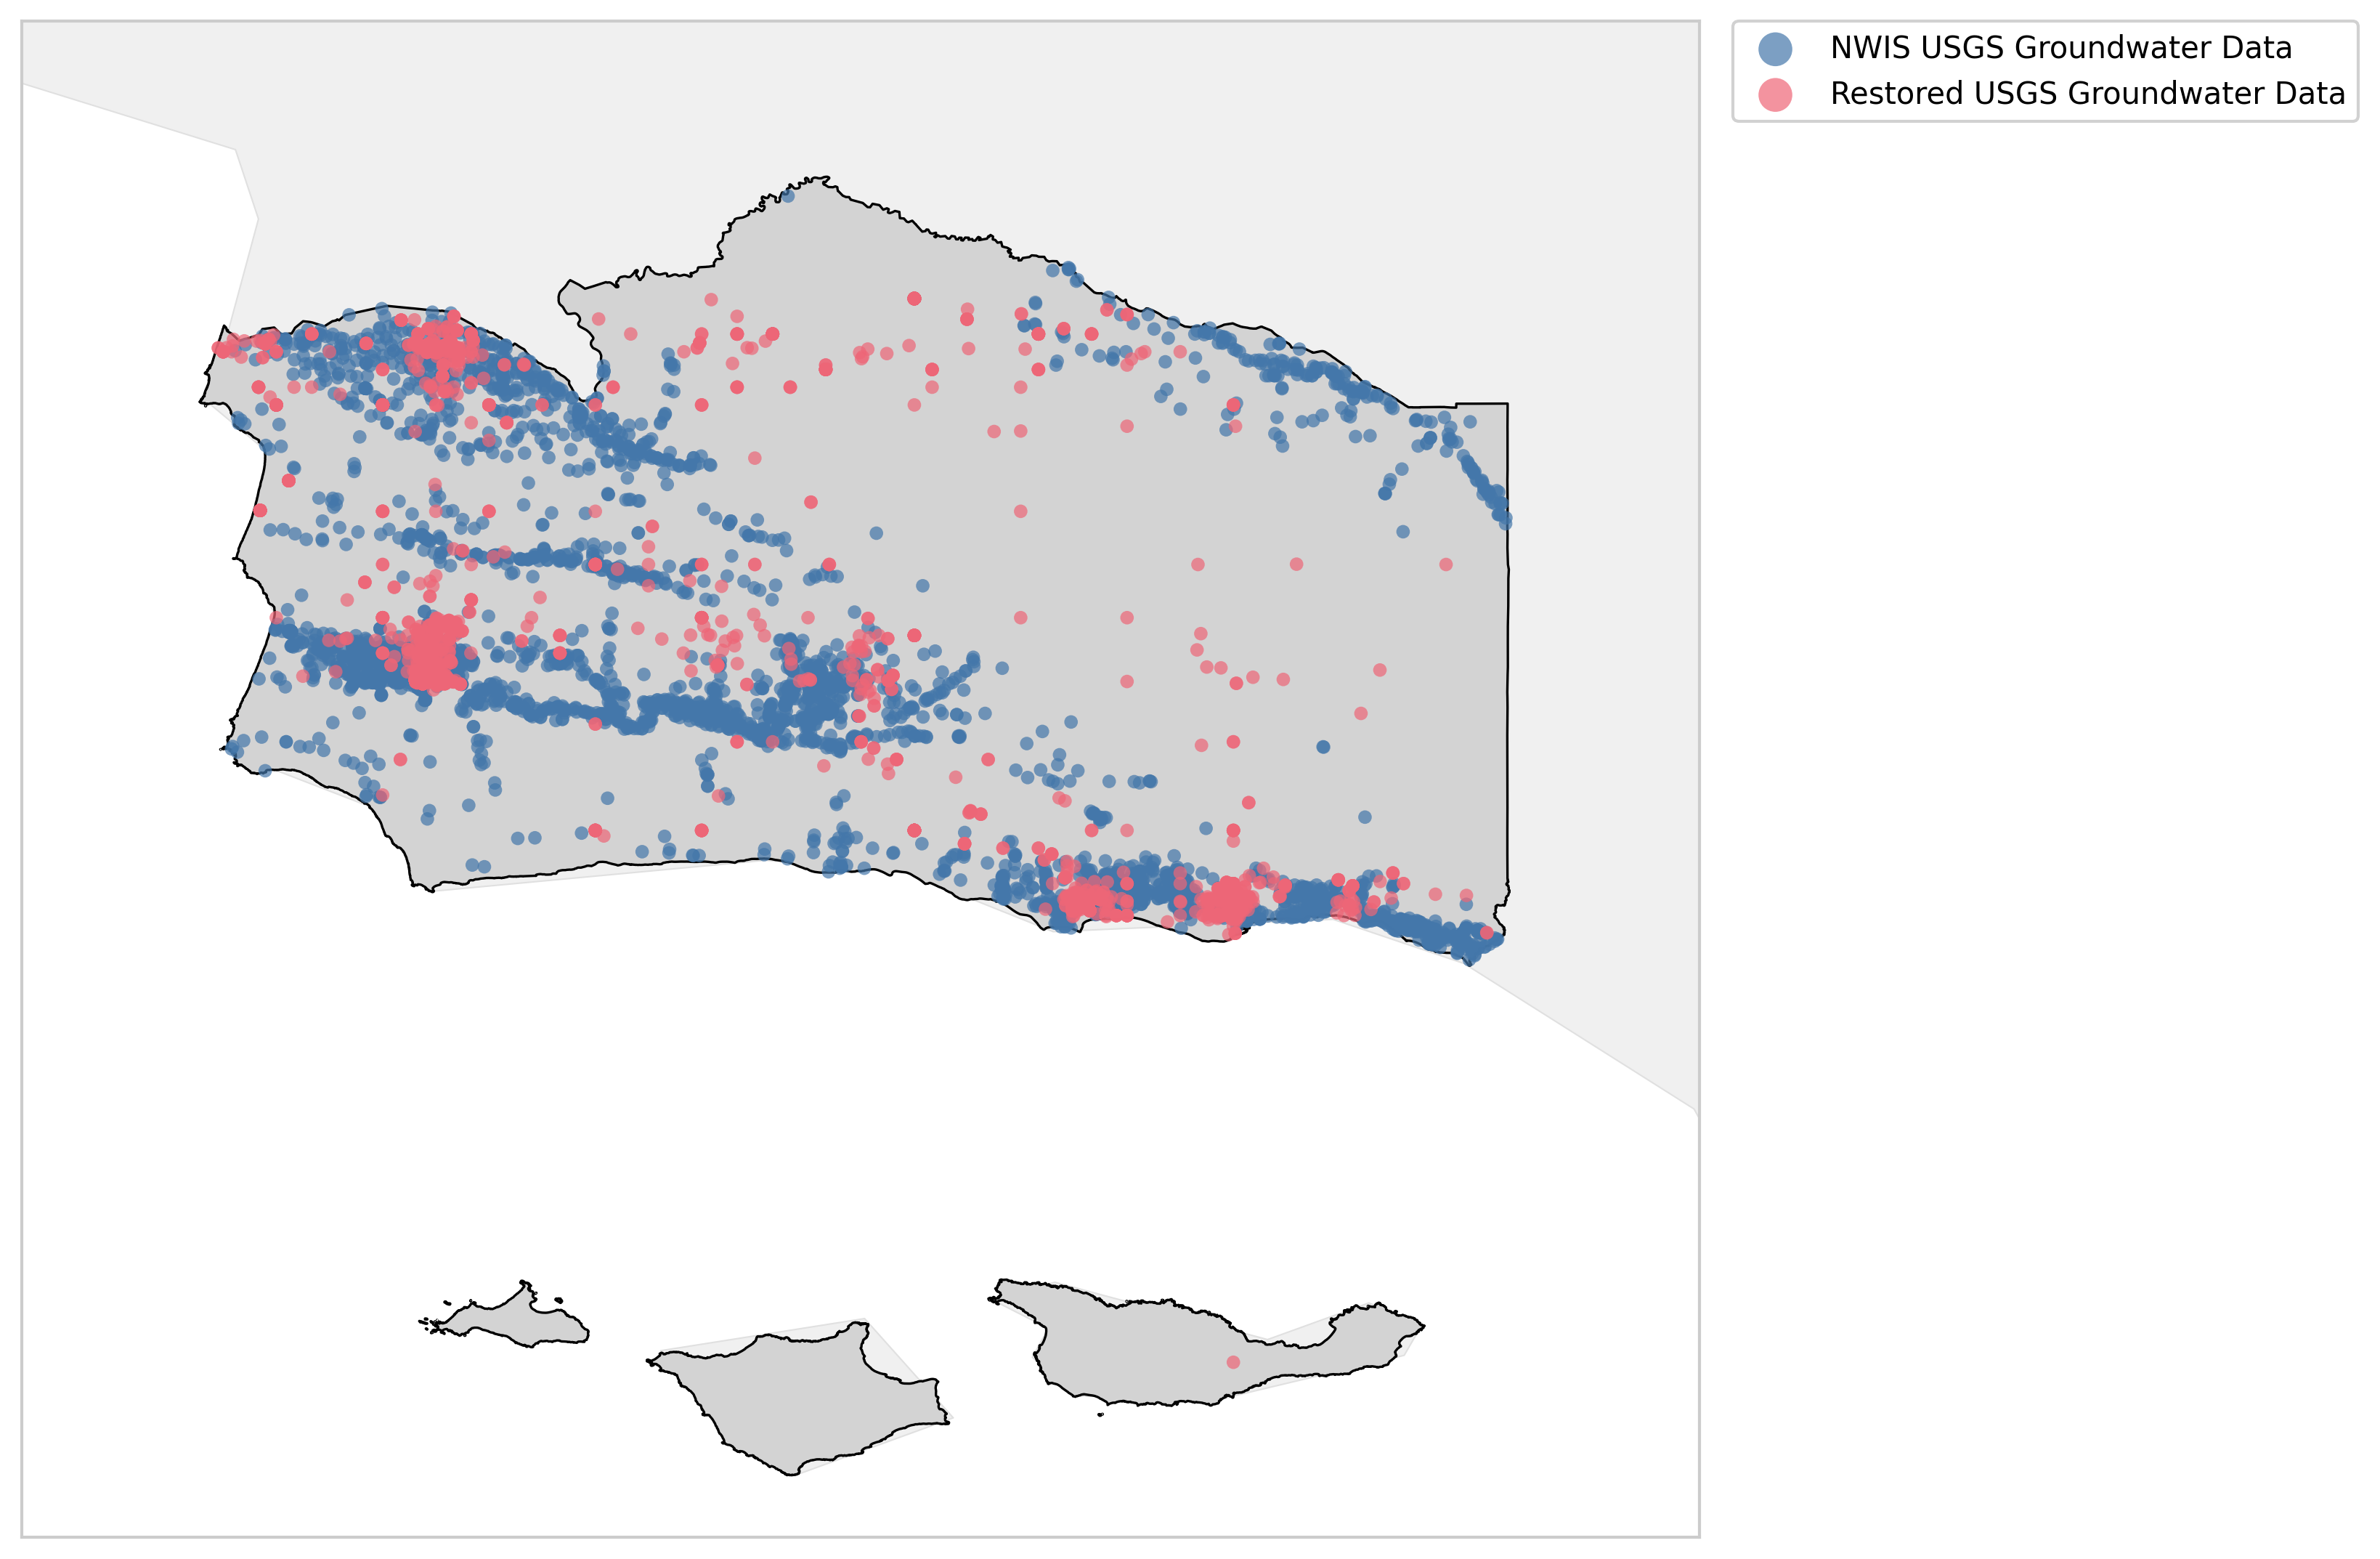

In [18]:
# ==== Groundwater Comparison Map: Historical vs New USGS ====
import os
import matplotlib.pyplot as plt
import geopandas as gpd

print("=== CREATING GROUNDWATER COMPARISON MAP ===")

# Check we have both datasets
if gdf_sb_existing is None:
    print("ERROR: No existing SB data loaded")
elif gdf_groundwater_sb is None:
    print("ERROR: No new USGS groundwater data loaded") 
else:
    # Filter existing data to just groundwater sites
    historical_gw = gdf_sb_existing[gdf_sb_existing['water_type_clean'] == 'Groundwater'].copy()
    
    # For new USGS data, we'll use the filtered 1820-1979 data if available
    if 'gdf_filtered' in locals() and gdf_filtered is not None:
        # Use the date-filtered data and group by site to avoid duplicates
        new_gw_summary = gdf_filtered.groupby('site_no').agg({
            'dec_lat_va': 'first',
            'dec_long_va': 'first',
            'station_nm': 'first'
        }).reset_index()
        
        # Create GeoDataFrame for new sites
        new_gw = gpd.GeoDataFrame(
            new_gw_summary,
            geometry=gpd.points_from_xy(new_gw_summary['dec_long_va'], new_gw_summary['dec_lat_va']),
            crs="EPSG:4326"
        )
    else:
        # Fallback: use all groundwater data but group by site
        new_gw_summary = gdf_groundwater_sb.groupby('site_no').agg({
            'dec_lat_va': 'first',
            'dec_long_va': 'first', 
            'station_nm': 'first'
        }).reset_index()
        
        new_gw = gpd.GeoDataFrame(
            new_gw_summary,
            geometry=gpd.points_from_xy(new_gw_summary['dec_long_va'], new_gw_summary['dec_lat_va']),
            crs="EPSG:4326"
        )
    
    print(f"Restored groundwater sites: {len(historical_gw):,}")
    print(f"NWIS USGS groundwater sites: {len(new_gw):,}")
    
    # Calculate aspect ratio based on data bounds (not arbitrary)
    width = SB_XMAX - SB_XMIN
    height = SB_YMAX - SB_YMIN
    aspect_ratio = width / height
    fig, ax = plt.subplots(figsize=(10, 10/aspect_ratio), dpi=300)
    
    # Add California state context
    try:
        ca_context_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\ca_shapefile\ca_poly.shp"
        if os.path.exists(ca_context_path):
            ca_context = gpd.read_file(ca_context_path).to_crs("EPSG:4326")
            ca_context_geom = ca_context.union_all() if hasattr(ca_context, "union_all") else ca_context.unary_union
            gpd.GeoSeries([ca_context_geom], crs="EPSG:4326").plot(
                ax=ax,
                color="#f0f0f0",
                edgecolor="#e0e0e0", 
                linewidth=0.5,
                zorder=0
            )
    except Exception:
        pass
    
    # Plot Santa Barbara County boundary
    if SB_COUNTY_GDF is not None:
        SB_COUNTY_GDF.plot(
            ax=ax,
            color="lightgray",
            edgecolor="black",
            linewidth=0.8,
            zorder=1
        )
    
    # Plot new USGS groundwater sites (bottom layer)  
    new_gw.plot(
        ax=ax,
        color='#4477AA',  # Blue from your colorblind-safe palette
        markersize=20,
        alpha=0.7, 
        edgecolor='none',
        zorder=2,
        label='NWIS USGS Groundwater Data'
    )
    
    # Plot historical groundwater sites (top layer)
    historical_gw.plot(
        ax=ax,
        color='#EE6677',  # Red from your colorblind-safe palette
        markersize=20,
        alpha=0.7,
        edgecolor='none',
        zorder=3,
        label='Restored USGS Groundwater Data'
    )
    
    # CONSISTENT extent setting (no arbitrary extensions)
    ax.set_xlim(SB_XMIN, SB_XMAX)
    ax.set_ylim(SB_YMIN, SB_YMAX)
    ax.set_aspect('equal')
    
    # Clean styling
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)
    
    # Add border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#cccccc')
        spine.set_linewidth(1.0)
    
    # Legend
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        markerscale=2.5,
        frameon=True,
        fancybox=True,
        framealpha=0.9
    )
    
    # Create output directory
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    
    # Save
    outfile = output_dir / "groundwater_comparison_historical_vs_usgs.png"
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    print(f"Saved: {outfile}")
    plt.show()

## Decadal plots of groundwater 

=== CREATING DECADAL GROUNDWATER MAP FROM CSV FILES ===
Loading NWIS USGS groundwater data...
Loaded NWIS USGS data: 3,794 sites
Loading restored USGS historical data...
Loaded restored data: 4,929 sites
Historical groundwater sites: 1,864
Combining datasets...
Combined groundwater data: 5,658 sites
  - NWIS USGS: 3,794
  - Restored USGS: 1,864
Loaded Santa Barbara County boundary
Saved decadal groundwater map: output\groundwater_decadal_map_1860s_1970s.png


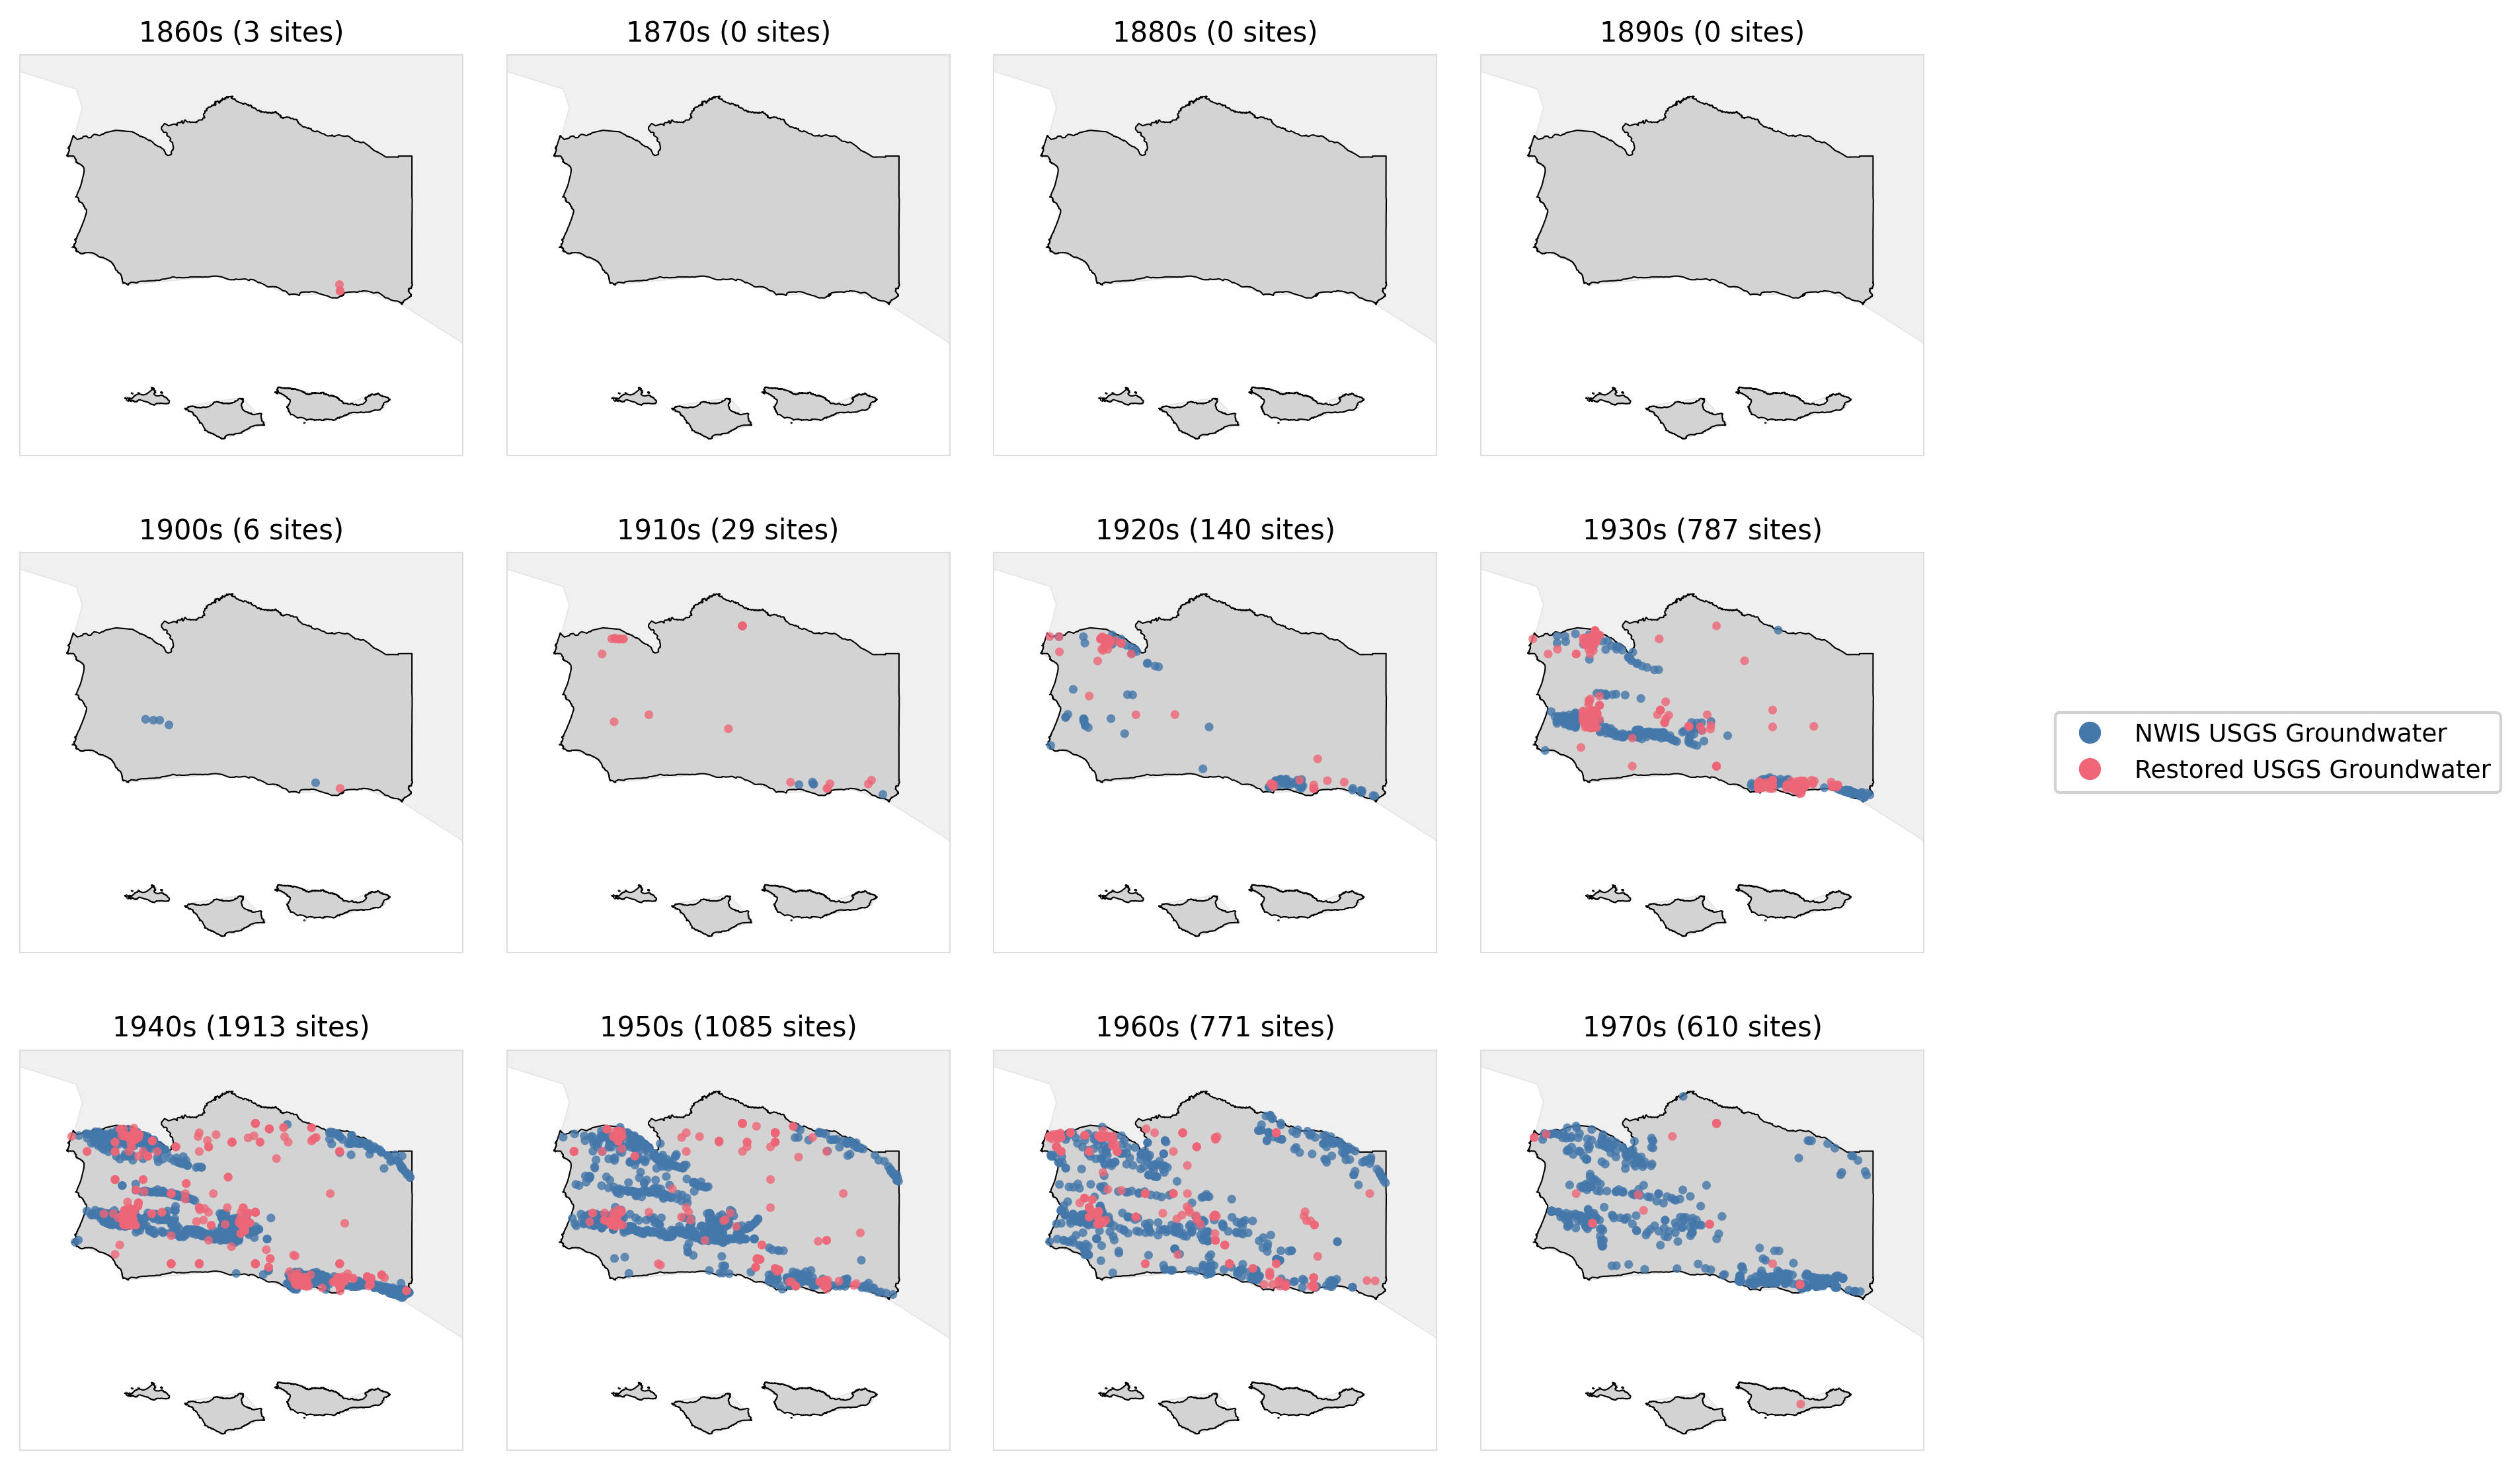


=== DECADAL SUMMARY ===
Sites by decade and data type:
data_type  NWIS USGS  Restored USGS
decade                             
1860.0             0              3
1900.0             5              1
1910.0             5             24
1920.0            81             59
1930.0           337            450
1940.0          1351            562
1950.0           896            189
1960.0           539            232
1970.0           580             30

Total sites by data type:
data_type
NWIS USGS        3794
Restored USGS    1864
Name: count, dtype: int64


In [19]:
# ==== Create Decadal Map for Groundwater Sites Only (Using CSV Files) ====
print("=== CREATING DECADAL GROUNDWATER MAP FROM CSV FILES ===")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
import os

# Define file paths
nwis_gw_csv = Path(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\sb_groundwater_sites_1820_1979.csv")
restored_csv = Path(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\plots\run_20250825_112711\santa_barbara_county\santa_barbara_sites.csv")

try:
    # Load NWIS USGS groundwater data
    print("Loading NWIS USGS groundwater data...")
    nwis_gw_df = pd.read_csv(nwis_gw_csv)
    print(f"Loaded NWIS USGS data: {len(nwis_gw_df):,} sites")
    
    # Create GeoDataFrame for NWIS data
    nwis_gw_gdf = gpd.GeoDataFrame(
        nwis_gw_df,
        geometry=gpd.points_from_xy(nwis_gw_df['longitude'], nwis_gw_df['latitude']),
        crs="EPSG:4326"
    )
    
    # Add decade and data type columns for NWIS data
    # Check which column name is used for start year
    if 'start_year' in nwis_gw_gdf.columns:
        nwis_gw_gdf['decade'] = (nwis_gw_gdf['start_year'] // 10) * 10
    elif 'year_start' in nwis_gw_gdf.columns:
        nwis_gw_gdf['decade'] = (nwis_gw_gdf['year_start'] // 10) * 10
    else:
        print("Warning: No start year column found in NWIS data")
        nwis_gw_gdf['decade'] = 1940  # Default decade
    
    nwis_gw_gdf['data_type'] = 'NWIS USGS'
    
    # Load restored historical data
    print("Loading restored USGS historical data...")
    restored_df = pd.read_csv(restored_csv)
    print(f"Loaded restored data: {len(restored_df):,} sites")
    
    # Filter to groundwater sites only
    historical_gw = restored_df[restored_df['water_type_clean'] == 'Groundwater'].copy()
    print(f"Historical groundwater sites: {len(historical_gw):,}")
    
    # Create GeoDataFrame for historical data
    historical_gw_gdf = gpd.GeoDataFrame(
        historical_gw,
        geometry=gpd.points_from_xy(historical_gw['lon_combined'], historical_gw['lat_combined']),
        crs="EPSG:4326"
    )
    
    # Add decade and data type columns for historical data
    # Check which column name is used for start year
    if 'start_year' in historical_gw_gdf.columns:
        historical_gw_gdf['decade'] = (historical_gw_gdf['start_year'] // 10) * 10
    elif 'year_start' in historical_gw_gdf.columns:
        historical_gw_gdf['decade'] = (historical_gw_gdf['year_start'] // 10) * 10
    else:
        print("Warning: No start year column found in historical data")
        historical_gw_gdf['decade'] = 1940  # Default decade
    
    historical_gw_gdf['data_type'] = 'Restored USGS'
    
    # Combine both datasets
    print("Combining datasets...")
    
    # Select relevant columns for plotting
    nwis_subset = nwis_gw_gdf[['geometry', 'decade', 'data_type']].copy()
    historical_subset = historical_gw_gdf[['geometry', 'decade', 'data_type']].copy()
    
    # Combine into single GeoDataFrame
    all_gw_data = gpd.GeoDataFrame(pd.concat([nwis_subset, historical_subset], ignore_index=True))
    
    print(f"Combined groundwater data: {len(all_gw_data):,} sites")
    print(f"  - NWIS USGS: {len(nwis_subset):,}")
    print(f"  - Restored USGS: {len(historical_subset):,}")
    
    # Load Santa Barbara County boundary for plotting
    sb_county_shapefile = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_shapefile\sb_county_shp.shp"
    
    try:
        sb_county = gpd.read_file(sb_county_shapefile)
        if sb_county.crs is None or sb_county.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
            sb_county = sb_county.to_crs("EPSG:4326")
        
        sb_county_geom = sb_county.union_all() if hasattr(sb_county, "union_all") else sb_county.unary_union
        SB_COUNTY_GDF = gpd.GeoSeries([sb_county_geom], crs="EPSG:4326")
        print("Loaded Santa Barbara County boundary")
    except FileNotFoundError:
        print("Warning: County boundary file not found - will use data bounds")
        SB_COUNTY_GDF = None
    
    # Define decade range (1860s to 1970s)
    decades = list(range(1860, 1980, 10))
    
    # Set up the plot grid (4x3 = 12 decades)
    fig, axes = plt.subplots(3, 4, figsize=(12, 8), dpi=300)
    axes = axes.flatten()
    
    # Adjust spacing to match your version
    plt.subplots_adjust(
        left=0.05,
        bottom=0.05,
        right=0.85,  # Leave space for legend
        top=0.95,
        wspace=0.1,
        hspace=0.15
    )
    
    # Colors for different data types
    colors = {
        'Restored USGS': '#EE6677',  # Red
        'NWIS USGS': '#4477AA'      # Blue
    }

    
    # Plot each decade
    for i, decade in enumerate(decades):
        ax = axes[i]
        
        # Filter data for this decade
        decade_data = all_gw_data[all_gw_data['decade'] == decade]
        
        # Add California state context (if available)
        try:
            ca_context_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\ca_shapefile\ca_poly.shp"
            if os.path.exists(ca_context_path):
                ca_context = gpd.read_file(ca_context_path).to_crs("EPSG:4326")
                ca_context_geom = ca_context.union_all() if hasattr(ca_context, "union_all") else ca_context.unary_union
                gpd.GeoSeries([ca_context_geom], crs="EPSG:4326").plot(
                    ax=ax,
                    color="#f0f0f0",  # Very light gray for context
                    edgecolor="#e0e0e0",
                    linewidth=0.3,  # Thinner lines for small panels
                    zorder=0
                )
        except Exception:
            pass
        
        # Plot Santa Barbara County boundary
        if SB_COUNTY_GDF is not None:
            SB_COUNTY_GDF.plot(
                ax=ax,
                color="lightgray",
                edgecolor="black",
                linewidth=0.5,
                zorder=1
            )
        
        # Plot data for each type (NWIS first, then historical on top)
        for data_type, color in [('NWIS USGS', colors['NWIS USGS']), ('Restored USGS', colors['Restored USGS'])]:
            type_data = decade_data[decade_data['data_type'] == data_type]
            if len(type_data) > 0:
                type_data.plot(
                    ax=ax,
                    color=color,
                    markersize=10,  # Smaller markers like your version
                    alpha=0.8,
                    edgecolor='none',
                    linewidth=0,
                    zorder=2 if data_type == 'NWIS USGS' else 3
                )
        
        # Set extent
        # CONSISTENT extent setting (same for all panels)
        ax.set_xlim(SB_XMIN, SB_XMAX)
        ax.set_ylim(SB_YMIN, SB_YMAX)
        ax.set_aspect('equal')
        
        # Clean styling - match your version's lighter borders
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(False)
        
        # Light border like your version
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('#dddddd')  # Lighter gray like your version
            spine.set_linewidth(0.5)
        
        # Title with decade and count (smaller font like your version)
        total_sites = len(decade_data)
        decade_label = f"{decade}s"
        ax.set_title(f"{decade_label} ({total_sites} sites)", 
                    fontsize=10, pad=5)
    
    # Add legend to match your version's positioning and styling
    from matplotlib.lines import Line2D
    
    legend_elements = [
        Line2D([0],[0], marker='o', linestyle='',
               markerfacecolor=colors['NWIS USGS'], 
               markeredgecolor='none',
               markersize=8, label='NWIS USGS Groundwater'),
        Line2D([0],[0], marker='o', linestyle='',
               markerfacecolor=colors['Restored USGS'], 
               markeredgecolor='none',
               markersize=8, label='Restored USGS Groundwater')
    ]
    
    fig.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(0.9, 0.5),  # Closer to plots like your version
        frameon=True,
        fancybox=True,
        framealpha=0.9,
        fontsize=9  # Smaller font like your version
    )
    
    # No overall title (removed to match your version)
    
    # Save the plot
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    
    outfile = output_dir / "groundwater_decadal_map_1860s_1970s.png"
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    print(f"Saved decadal groundwater map: {outfile}")
    
    plt.show()
    
    # Print summary statistics
    print(f"\n=== DECADAL SUMMARY ===")
    decade_summary = all_gw_data.groupby(['decade', 'data_type']).size().unstack(fill_value=0)
    print("Sites by decade and data type:")
    print(decade_summary)
    
    print(f"\nTotal sites by data type:")
    data_type_summary = all_gw_data['data_type'].value_counts()
    print(data_type_summary)

except FileNotFoundError as e:
    print(f"ERROR: Could not find required CSV file: {e}")
    print("Please check the file paths:")
    print(f"  NWIS GW data: {nwis_gw_csv}")
    print(f"  Restored data: {restored_csv}")
except Exception as e:
    print(f"ERROR: {e}")
    print("Please check that both CSV files exist and have the expected columns.")